Simulating patient cardiac risk over 6 months...
Total cardiac anomalies simulated: 1


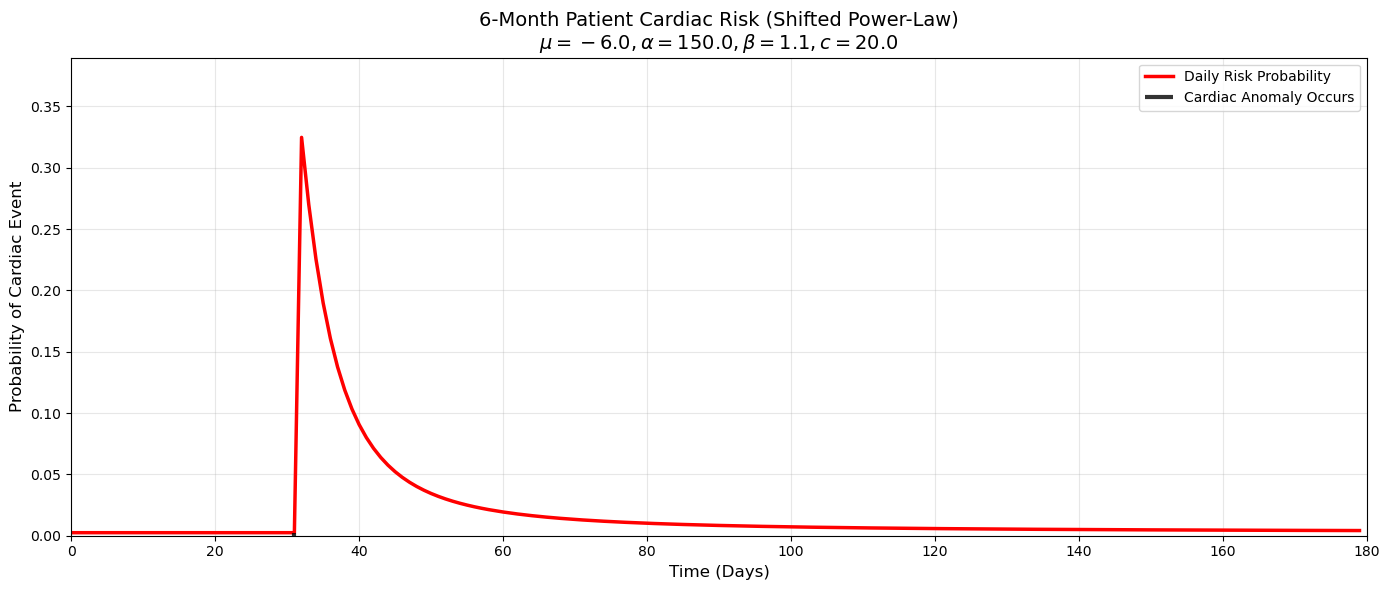

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_cardiac_bdhp_shifted(T, mu, alpha, beta, c):
    """
    Simulates a Bernoulli Discrete Hawkes Process with a Logistic Link 
    and a Shifted Power-Law Kernel (Omori-Utsu).
    """
    Y = np.zeros(T, dtype=int)  # Binary event array
    P = np.zeros(T)             # Probability array p_t
    
    # Pre-compute the Shifted Power-Law kernel weights
    k_values = np.arange(1, T + 1)
    weights = alpha / ((k_values + c) ** beta)
    
    for t in range(T):
        if t == 0:
            history_term = 0.0
        else:
            # Y[t-1::-1] slices the history backwards
            history_term = np.sum(Y[t-1::-1] * weights[:t])
            
        # Apply the logistic link function
        logit_p = mu + history_term
        p_t = 1.0 / (1.0 + np.exp(-logit_p))
        
        # Simulate whether a cardiac event occurs today
        event = np.random.binomial(1, p_t)
        
        Y[t] = event
        P[t] = p_t
        
    return Y, P

# ==========================================
# Run Simulation
# ==========================================
np.random.seed(42)  

T_days = 180        # 6 months of daily monitoring
mu_base = -6.0      # Low baseline daily risk (~0.24%)

# Shifted Power-Law Parameters
c_shift = 20.0      # Flattens the initial drop-off
beta_decay = 1.1   # Must be > 1 to prevent explosion
alpha_scale = 150.0 # Scaled up to counteract the c_shift.

print("Simulating patient cardiac risk over 6 months...")

# Rejection sampling: Keep simulating until we get a timeline with exactly 1 event
while True:
    Y_sim, P_sim = simulate_cardiac_bdhp_shifted(T_days, mu_base, alpha_scale, beta_decay, c_shift)
    if np.sum(Y_sim) == 1:
        break

print(f"Total cardiac anomalies simulated: 1")

# ==========================================
# Visualization
# ==========================================
plt.figure(figsize=(14, 6))

# Plot the underlying probability of an event p_t
plt.plot(np.arange(T_days), P_sim, color='red', lw=2.5, label='Daily Risk Probability')

# Plot the actual events as vertical lines
event_times = np.where(Y_sim == 1)[0]
plt.vlines(event_times, ymin=0, ymax=P_sim[event_times], 
           color='black', alpha=0.8, lw=3, label='Cardiac Anomaly Occurs')

# Formatting
plt.title(f"6-Month Patient Cardiac Risk (Shifted Power-Law)\n$\\mu={mu_base}, \\alpha={alpha_scale}, \\beta={beta_decay}, c={c_shift}$", fontsize=14)
plt.xlabel("Time (Days)", fontsize=12)
plt.ylabel("Probability of Cardiac Event", fontsize=12)
plt.ylim(0, max(P_sim) * 1.2 if max(P_sim) > 0 else 1)
plt.xlim(0, T_days)
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")
plt.tight_layout()

plt.show()